In [10]:
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import replace
from IPython.display import clear_output
from astropy.table import Table

import run_config
import utils_lya_halo

from run_config import cfg, smoke
from utils_lya_halo import (run_extract, run_stack, read_galaxy_fits, measure, plotting, analysis, multicat,
core, PipelineConfig, stack, selection)
from utils_lya_halo.io import read_galaxy_fits, apply_finite_cut
from utils_lya_halo.measure import measure_all_bins, integrated_line_flux
from utils_lya_halo.stack import build_stacks

%matplotlib inline

LYA_REST = PipelineConfig.LYA_REST

import warnings
from astropy.utils.exceptions import AstropyUserWarning

warnings.filterwarnings(
    "ignore",
    message="Input data contains invalid values.*",
    category=AstropyUserWarning,
)

# Reading in output and stacking

In [4]:
random_seed = 10

cfg_cos = replace(cfg, 
    catalog="3DHST",
    field="COSMOS",
    bin_mode='kpc',
    flux_unit="flux_arcsec2",           # 'raw' | 'flux_arcsec2' | 'L_fiber' | 'L_kpc2'
    rest_density=False,
    bins=[0, 5, 10, 15, 20, 30, 40, 60, 80, 160, 320, 800],
    catalog_path="catalogs/lya_halo_catalog_cuts/ALL_oiii_sn3_3dhst_catalog.txt",
    rest_wave_min=1100,
    rest_wave_max=1300,
    bg_inner_arcsec=57,
    bg_outer_arcsec=63,
    mask_method='image')

cfg_egs = replace(cfg, 
    catalog="3DHST",
    field="AEGIS",
    bin_mode='kpc',
    flux_unit="flux_arcsec2",           # 'raw' | 'flux_arcsec2' | 'L_fiber' | 'L_kpc2'
    rest_density=False,
    bins=[0, 5, 10, 15, 20, 30, 40, 60, 80, 160, 320, 800],
    catalog_path="catalogs/lya_halo_catalog_cuts/ALL_oiii_sn3_3dhst_catalog.txt",
    rest_wave_min=1100,
    rest_wave_max=1300,
    bg_inner_arcsec=57,
    bg_outer_arcsec=63,
    mask_method='image')

cfg2 = replace(cfg, 
    catalog="3DHST",
    field="BOTH",
    bin_mode='kpc',
    flux_unit="flux_arcsec2",           # 'raw' | 'flux_arcsec2' | 'L_fiber' | 'L_kpc2'
    rest_density=False,
    bins=[0, 5, 10, 15, 20, 30, 40, 60, 80, 160, 320, 800],
    catalog_path="catalogs/lya_halo_catalog_cuts/ALL_oiii_sn3_3dhst_catalog.txt",
    rest_wave_min=1100,
    rest_wave_max=1300,
    bg_inner_arcsec=57,
    bg_outer_arcsec=63,
    mask_method='image')

stacks_cos = run_stack(cfg_cos)
stacks_egs = run_stack(cfg_egs)
stacks = run_stack(cfg2)

Finite-spectrum cut (bin 10, > 100 px): kept 255 / 256 galaxies
Finite-spectrum cut (bin 10, > 100 px): kept 322 / 375 galaxies
Loaded BOTH: 375 AEGIS + 256 COSMOS = 631
Finite-spectrum cut (bin 10, > 100 px): kept 577 / 631 galaxies


In [8]:
wave  = stacks["rest_wave"]
raw_flux = stacks["stacks"]["biweight"]["flux"]
bounds = (1211.67, 1219.67) #tuple(cfg2.line_window)
flux_curve = []
for r in range(raw_flux.shape[0]):
    res = integrated_line_flux(wave, raw_flux[r], bounds=bounds)
    flux_curve.append(res["flux_integral"])
    print(r, res["flux_integral"])

0 6.8311318744987475e-19
1 5.774602931081384e-19
2 4.556307445558164e-19
3 3.244164780806124e-19
4 1.6997131888443459e-19
5 8.836549907434166e-20
6 3.595813590849351e-20
7 1.396564068016721e-20
8 8.067137233120301e-21
9 9.80291112966429e-22
10 2.3420655071396147e-23


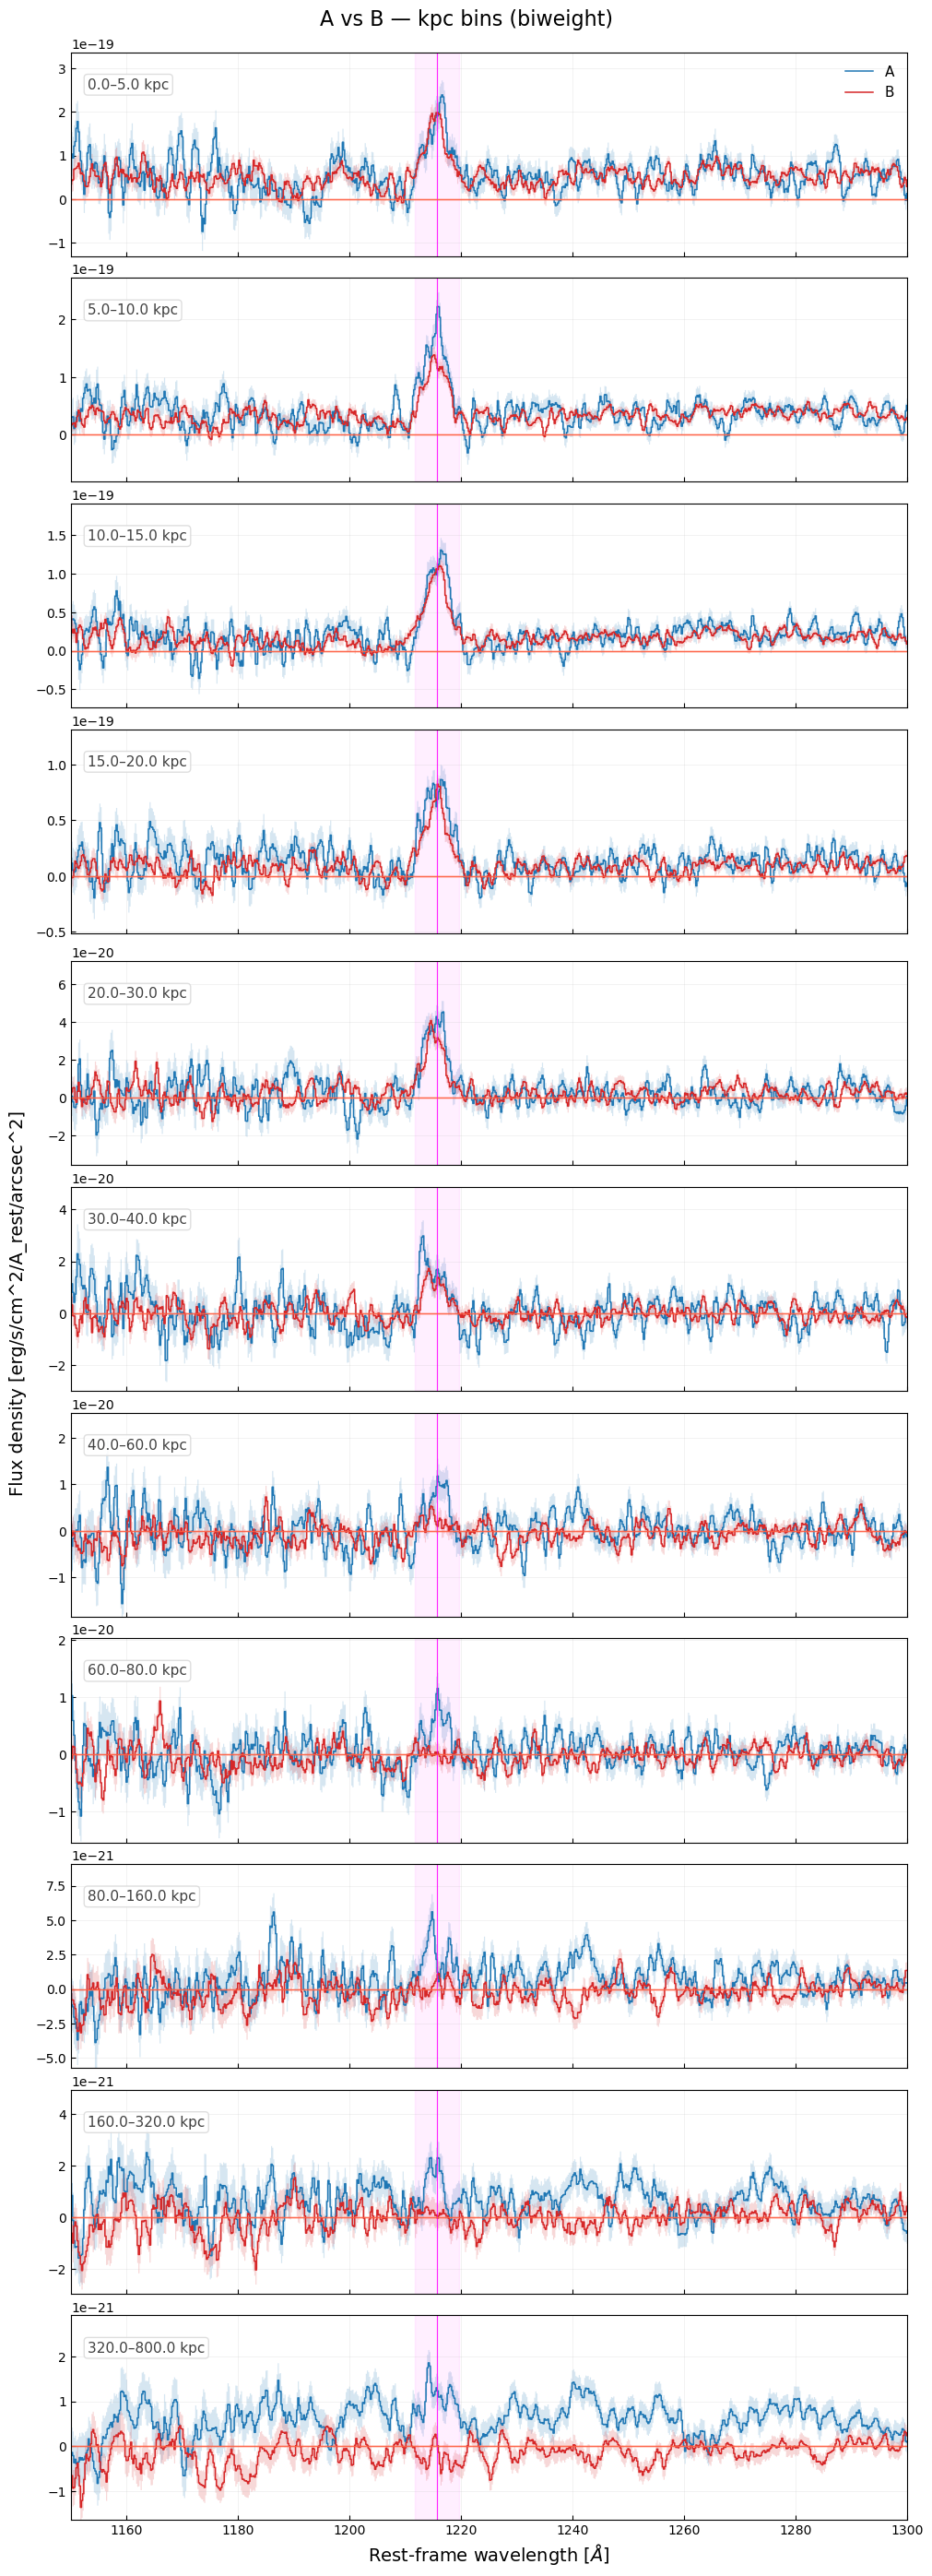

(<Figure size 1000x2750 with 11 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: xlabel='Rest-frame wavelength [$\\AA$]'>], dtype=object))

In [38]:
plotting.plot_stack_panels_two(stacks_cos, stacks_egs,
    method="biweight",
    distance_type="kpc",
    title=None,
    xlim=(1150, 1300),
    lya_window=4,
    figsize_width=10,
    panel_height=2.5,
    show_err=True,
    smooth=None,
    savepath=None,
    dpi=300)

# Looking into datapoints

In [11]:
catalog = Table.read("catalogs/lya_halo_catalog_cuts/ALL_oiii_sn3_3dhst_catalog.txt", format='ascii')
cat_cos = catalog[catalog['FIELD'] == 'COSMOS']
cat_egs = catalog[catalog['FIELD'] == 'AEGIS']

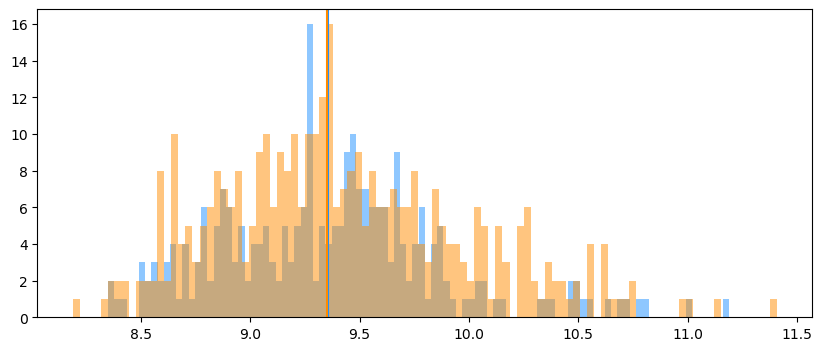

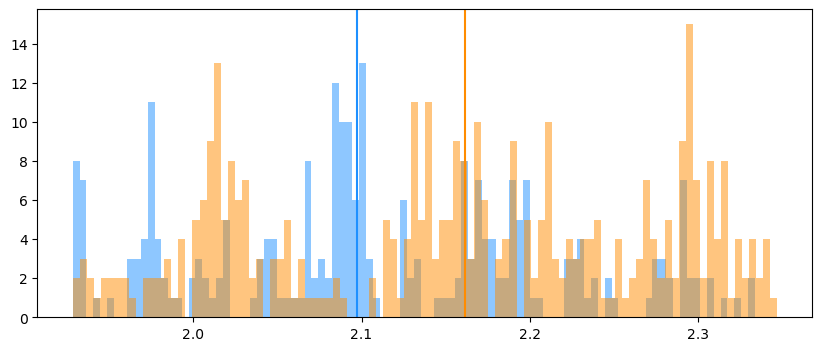

In [66]:
plt.figure(figsize=(10, 4))
plt.hist(cat_cos['MASS_50'], 100, alpha=0.5, color='dodgerblue')
plt.axvline(np.nanmedian(cat_cos['MASS_50']), color='dodgerblue')
plt.hist(cat_egs['MASS_50'], 100, alpha=0.5, color='darkorange')
plt.axvline(np.nanmedian(cat_egs['MASS_50']), color='darkorange')

plt.figure(figsize=(10, 4))
plt.hist(cat_cos['z'], 100, alpha=0.5, color='dodgerblue')
plt.axvline(np.nanmedian(cat_cos['z']), color='dodgerblue')
plt.hist(cat_egs['z'], 100, alpha=0.5, color='darkorange')
plt.axvline(np.nanmedian(cat_egs['z']), color='darkorange')

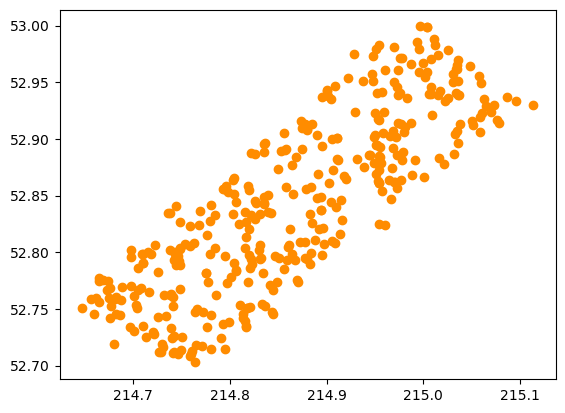

In [69]:
#plt.scatter(cat_cos['RA'], cat_cos['DEC'], color='dodgerblue')
plt.scatter(cat_egs['RA'], cat_egs['DEC'], color='darkorange')

# Comparing the Flux Profiles

In [12]:
cfg_cos_fast = replace(cfg_cos, n_bootstrap=1000)
cfg_egs_fast = replace(cfg_egs, n_bootstrap=1000)

#Basic bootstrap to get fiducial measurements
fast_boot_cos = analysis.run_measurement_suite(cfg_cos_fast, stacks_cos)
fast_boot_egs = analysis.run_measurement_suite(cfg_egs_fast, stacks_egs)

▶ bootstrap [median50]  |  nboot=1000  stack=biweight  centroid=median50  window=(1212.67,1218.67)  cont=median  side_ratio=True  stack_err=True  seed=1


bootstrap [median50]:   0%|          | 0/1000 [00:00<?, ?it/s]


line moments (fiducial stack, no bootstrap):
  0-5: v=+40.9  σ=352.8  skew=-0.286
  5-10: v=-15.3  σ=358.8  skew=+0.022
  10-15: v=+41.9  σ=363.5  skew=-0.155
  15-20: v=-2.5  σ=376.8  skew=-0.001
  20-30: v=-57.1  σ=362.1  skew=+0.032
  30-40: v=-135.1  σ=413.4  skew=+0.333
  40-60: v=+34.5  σ=364.4  skew=-0.366
  60-80: v=+59.3  σ=355.4  skew=-0.478
  80-160: v=-74.4  σ=402.5  skew=+0.570
  160-320: v=-124.2  σ=235.3  skew=-0.006
  320-800: v=+27.8  σ=391.8  skew=+0.387
▶ bootstrap [median50]  |  nboot=1000  stack=biweight  centroid=median50  window=(1212.67,1218.67)  cont=median  side_ratio=True  stack_err=True  seed=1


bootstrap [median50]:   0%|          | 0/1000 [00:00<?, ?it/s]


line moments (fiducial stack, no bootstrap):
  0-5: v=-31.0  σ=354.9  skew=+0.147
  5-10: v=-12.1  σ=371.6  skew=+0.021
  10-15: v=-0.9  σ=354.3  skew=-0.031
  15-20: v=-18.8  σ=357.4  skew=-0.005
  20-30: v=-82.5  σ=332.3  skew=+0.239
  30-40: v=-87.9  σ=379.4  skew=+0.320
  40-60: v=-78.1  σ=396.6  skew=+0.288
  60-80: v=-271.6  σ=338.3  skew=+1.031
  80-160: v=+212.8  σ=324.4  skew=-0.472
  160-320: v=-256.4  σ=306.0  skew=+0.693
  320-800: v=-90.6  σ=67.2  skew=-0.050


In [13]:
_PALETTE = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#ff7f0e", "#17becf"]


def compare_fields(datasets, reference, residual="percent", figsize=(7.5, 6.5),
                   title=None):
    """
    Overlay one or more measured profiles against a reference, with a
    residual panel underneath (each field vs the reference).

    datasets : list of dicts, one per field. Each dict:
        "label" : str
        "r"     : radii [kpc]
        "sb"    : surface brightness
        "lo"    : (optional) lower bound  -> error bars if both lo & hi given
        "hi"    : (optional) upper bound
        "color" : (optional) matplotlib color
      Omit lo/hi to plot the FIDUCIAL only (points + line, no error bars).

    reference : dict with the same keys (e.g. digitized Niemeyer). lo/hi optional.

    residual : 'percent' -> 100*(field-ref)/ref ; 'ratio' -> field/ref.
               The reference is interpolated (log-log) onto each field's radii.

    Returns (fig, (ax_top, ax_res)).
    """
    fig, (ax, axr) = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.07})

    # ---- reference (plotted as open black squares) ----
    rr = np.asarray(reference["r"], float)
    sr = np.asarray(reference["sb"], float)
    yerr_ref = None
    if reference.get("lo") is not None and reference.get("hi") is not None:
        yerr_ref = np.vstack([sr - np.asarray(reference["lo"], float),
                              np.asarray(reference["hi"], float) - sr])
    ax.errorbar(rr, sr, yerr=yerr_ref, fmt="s--", color="k", mfc="none",
                ms=7, lw=1.2, capsize=3, label=reference.get("label", "reference"))

    good = np.isfinite(sr) & (sr > 0)
    log_rr, log_sr = np.log10(rr[good]), np.log10(sr[good])

    # ---- each measured field ----
    for i, d in enumerate(datasets):
        r = np.asarray(d["r"], float)
        sb = np.asarray(d["sb"], float)
        c = d.get("color", _PALETTE[i % len(_PALETTE)])
        yerr = None
        if d.get("lo") is not None and d.get("hi") is not None:
            yerr = np.vstack([sb - np.asarray(d["lo"], float),
                              np.asarray(d["hi"], float) - sb])
        ax.errorbar(r, sb, yerr=yerr, fmt="o-", color=c, capsize=3, lw=1.5,
                    label=d["label"])

        ref_at_r = 10**np.interp(np.log10(r), log_rr, log_sr)
        with np.errstate(invalid="ignore", divide="ignore"):
            res = (100.0*(sb-ref_at_r)/ref_at_r if residual == "percent"
                   else sb/ref_at_r)
        axr.plot(r, res, "o-", color=c)

    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_ylabel(r"SB [erg s$^{-1}$ cm$^{-2}$ arcsec$^{-2}$]")
    ax.legend(frameon=False)
    ax.grid(alpha=0.3, which="both")
    if title:
        ax.set_title(title)

    if residual == "percent":
        axr.axhline(0, color="gray", ls=":"); axr.set_ylabel("% diff")
    elif residual == "ratio":
        axr.axhline(1, color="gray", ls=":"); axr.set_ylabel("field / ref")
    else:
        raise ValueError("residual must be 'percent' or 'ratio'")
    axr.set_xscale("log"); axr.set_xlabel("r [kpc]")
    axr.grid(alpha=0.3, which="both")
    return fig, (ax, axr)

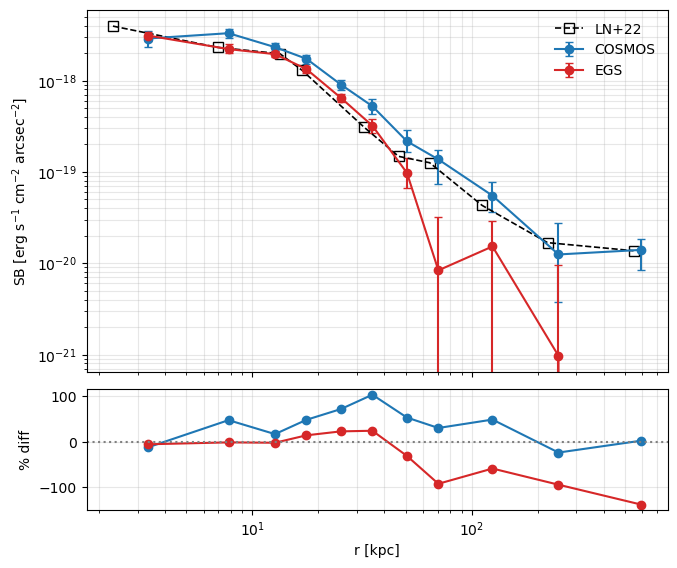

In [14]:
r = np.array([3.33, 7.78, 12.67, 17.62, 25.33, 35.24, 50.67, 70.48, 124.44, 248.89, 594.29])

cosmos = {"label": "COSMOS", "r": r, "sb": fast_boot_cos["total_flux_fid"],
          "lo": fast_boot_cos["total_flux_lo"], "hi": fast_boot_cos["total_flux_hi"]}  # with bands

egs    = {"label": "EGS",    "r": r, "sb": fast_boot_egs["total_flux_fid"],
          "lo": fast_boot_egs["total_flux_lo"], "hi": fast_boot_egs["total_flux_hi"]}  # with bands

ref = {"label": "LN+22",
       "r":  np.array([2.31, 6.94, 13.34, 16.82, 32.34, 46.40, 64.33, 111.54, 221.90, 547.32]),
       "sb": np.array([3.95e-18, 2.31e-18, 1.97e-18, 1.30e-18, 3.08e-19,
                       1.48e-19, 1.26e-19, 4.30e-20, 1.68e-20, 1.37e-20])}

compare_fields([cosmos, egs], ref, residual="percent")
plt.show()

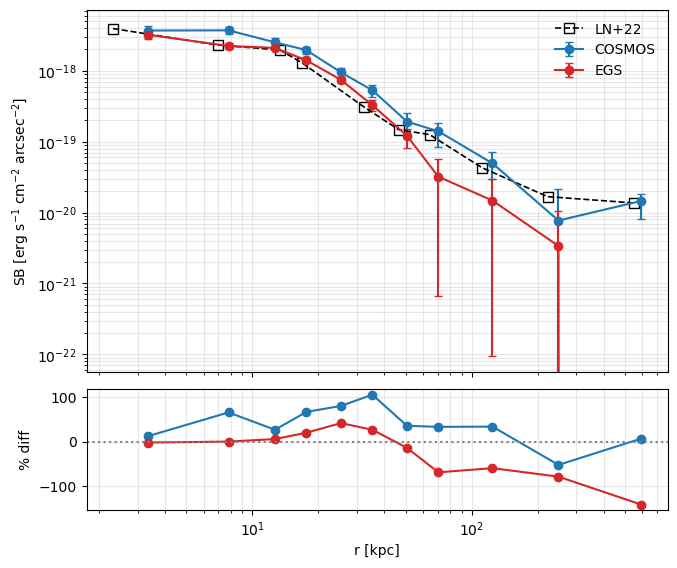

In [89]:
r = np.array([3.33, 7.78, 12.67, 17.62, 25.33, 35.24, 50.67, 70.48, 124.44, 248.89, 594.29])

cosmos = {"label": "COSMOS", "r": r, "sb": fast_boot_cos["total_flux_fid"],
          "lo": fast_boot_cos["total_flux_lo"], "hi": fast_boot_cos["total_flux_hi"]}  # with bands

egs    = {"label": "EGS",    "r": r, "sb": fast_boot_egs["total_flux_fid"],
          "lo": fast_boot_egs["total_flux_lo"], "hi": fast_boot_egs["total_flux_hi"]}  # with bands

ref = {"label": "LN+22",
       "r":  np.array([2.31, 6.94, 13.34, 16.82, 32.34, 46.40, 64.33, 111.54, 221.90, 547.32]),
       "sb": np.array([3.95e-18, 2.31e-18, 1.97e-18, 1.30e-18, 3.08e-19,
                       1.48e-19, 1.26e-19, 4.30e-20, 1.68e-20, 1.37e-20])}

compare_fields([cosmos, egs], ref, residual="percent")
plt.show()

# Bootstrap for Errors

In [16]:
# Stage 3: run everything
boot = analysis.run_measurement_suite(cfg2, stacks)

▶ bootstrap [median50]  |  nboot=2000  stack=biweight  centroid=median50  window=(1212.67,1218.67)  cont=median  side_ratio=True  stack_err=True  seed=1


bootstrap [median50]:   0%|          | 0/2000 [00:00<?, ?it/s]


line moments (fiducial stack, no bootstrap):
  0-5: v=+0.6  σ=354.7  skew=-0.001
  5-10: v=-9.4  σ=366.4  skew=+0.005
  10-15: v=+20.6  σ=355.5  skew=-0.113
  15-20: v=-7.4  σ=365.1  skew=-0.006
  20-30: v=-66.1  σ=349.0  skew=+0.128
  30-40: v=-110.9  σ=398.5  skew=+0.298
  40-60: v=-13.3  σ=385.9  skew=-0.073
  60-80: v=+0.3  σ=364.8  skew=-0.283
  80-160: v=+23.2  σ=403.3  skew=+0.184
  160-320: v=-143.8  σ=247.3  skew=+0.166
  320-800: v=-125.0  σ=214.5  skew=+1.194


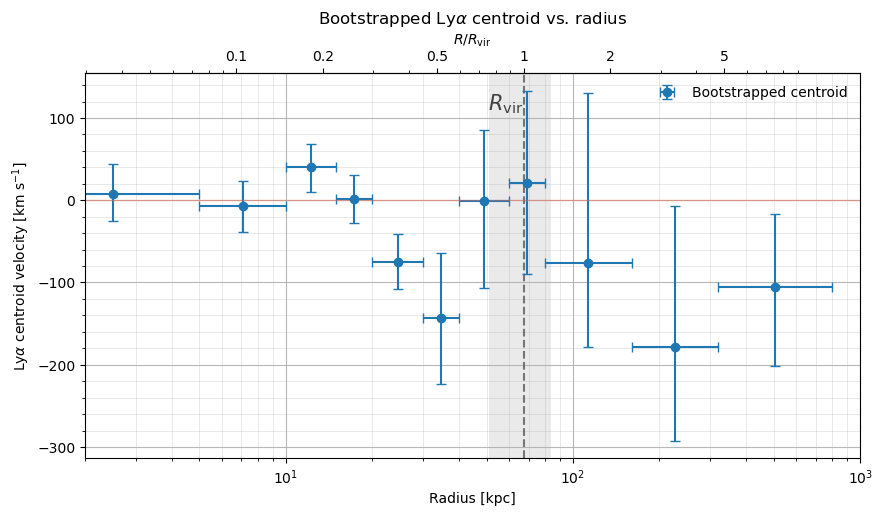

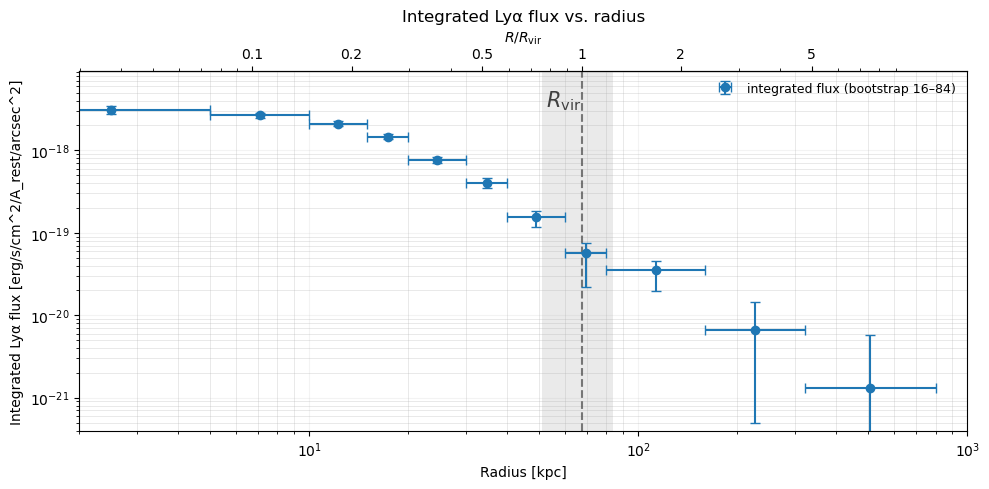

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Integrated Lyα flux vs. radius'}, xlabel='Radius [kpc]', ylabel='Integrated Lyα flux [erg/s/cm^2/A_rest/arcsec^2]'>)

In [18]:
xlims = (2, 1000)

#Radial profiles
analysis.plot_centroid_profile(boot, stacks,
    ylims=None,
    xlims=xlims,
    figsize=(10, 5))
analysis.plot_flux_profile(boot, stacks,
    ylims=None,
    xlims=xlims,
    figsize=(10, 5))

In [17]:
def compare_profiles(r_mine, sb_mine, r_paper, sb_paper,
                     sb_mine_lo=None, sb_mine_hi=None,
                     sb_paper_lo=None, sb_paper_hi=None,
                     label_mine="VDFI", label_paper="LN+22",
                     residual="percent", figsize=(7.5, 6.5)):
    """
    Overlay two SB(r) profiles with a residual panel underneath.

    Required:
        r_mine, sb_mine    : your radii [kpc] and surface brightness
        r_paper, sb_paper  : comparison radii and surface brightness
    Optional:
        *_lo / *_hi        : lower/upper bounds -> drawn as error bars
        residual           : 'percent' -> 100*(mine-paper)/paper
                             'ratio'   -> mine/paper
        The paper profile is interpolated (in log-log) onto YOUR radii so the
        residual is evaluated at your bin centers.

    Returns (fig, (ax_top, ax_res)) and prints the residual table.
    """
    r_mine, sb_mine   = np.asarray(r_mine, float),  np.asarray(sb_mine, float)
    r_paper, sb_paper = np.asarray(r_paper, float), np.asarray(sb_paper, float)

    fig, (ax, axr) = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.07})

    # ---- top: overlay ----
    yerr_mine = None
    if sb_mine_lo is not None and sb_mine_hi is not None:
        yerr_mine = np.vstack([sb_mine - np.asarray(sb_mine_lo, float),
                               np.asarray(sb_mine_hi, float) - sb_mine])
    yerr_paper = None
    if sb_paper_lo is not None and sb_paper_hi is not None:
        yerr_paper = np.vstack([sb_paper - np.asarray(sb_paper_lo, float),
                                np.asarray(sb_paper_hi, float) - sb_paper])

    ax.errorbar(r_mine, sb_mine, yerr=yerr_mine, fmt="o-", color="#1f77b4",
                capsize=3, lw=1.5, label=label_mine)
    ax.errorbar(r_paper, sb_paper, yerr=yerr_paper, fmt="s--", color="k",
                mfc="none", ms=7, capsize=3, lw=1.2, label=label_paper)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_ylabel(r"SB [erg s$^{-1}$ cm$^{-2}$ arcsec$^{-2}$]")
    ax.legend(frameon=False)
    ax.grid(alpha=0.3, which="both")

    # ---- bottom: residual (paper interpolated in log-log onto your radii) ----
    good = np.isfinite(sb_paper) & (sb_paper > 0)
    paper_at_mine = 10**np.interp(np.log10(r_mine),
                                  np.log10(r_paper[good]),
                                  np.log10(sb_paper[good]))
    with np.errstate(invalid="ignore", divide="ignore"):
        if residual == "percent":
            res = 100.0 * (sb_mine - paper_at_mine) / paper_at_mine
            axr.axhline(0, color="gray", ls=":")
            axr.set_ylabel("% diff")
        elif residual == "ratio":
            res = sb_mine / paper_at_mine
            axr.axhline(1, color="gray", ls=":")
            axr.set_ylabel("mine / paper")
        else:
            raise ValueError("residual must be 'percent' or 'ratio'")

    axr.plot(r_mine, res, "o-", color="#d62728")
    axr.set_xscale("log")
    axr.set_xlabel("r [kpc]")
    axr.grid(alpha=0.3, which="both")

    print(f"{'r[kpc]':>8} {'mine':>11} {'paper(interp)':>14} {residual:>10}")
    for r, m, p, v in zip(r_mine, sb_mine, paper_at_mine, res):
        print(f"{r:8.2f} {m:11.3e} {p:14.3e} {v:10.2f}")
    return fig, (ax, axr)

  r[kpc]        mine  paper(interp)    percent
    3.33   3.360e-18      3.305e-18       1.68
    7.78   2.832e-18      2.247e-18      26.08
   12.67   2.265e-18      1.995e-18      13.55
   17.62   1.619e-18      1.174e-18      37.92
   25.33   8.237e-19      5.276e-19      56.13
   35.24   4.068e-19      2.587e-19      57.24
   50.67   1.468e-19      1.417e-19       3.61
   70.48   7.542e-20      1.054e-19     -28.45
  124.44   3.052e-20      3.703e-20     -17.57
  248.89   6.013e-21      1.637e-20     -63.27
  594.29   2.016e-21      1.370e-20     -85.28


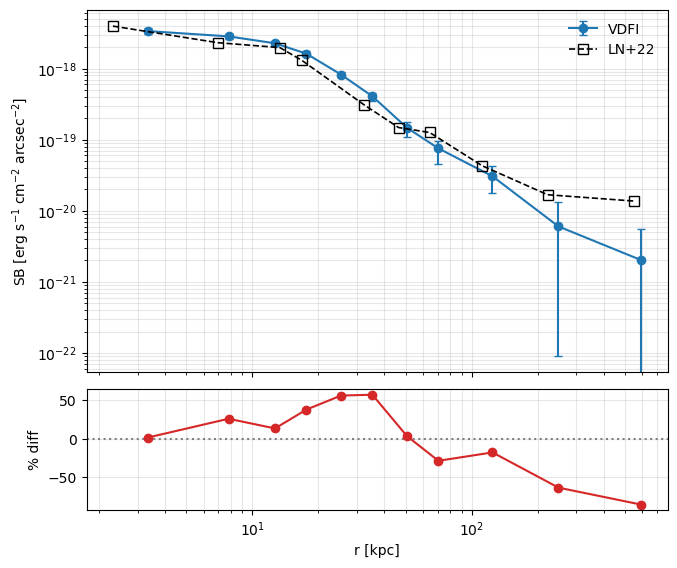

In [79]:
# YOUR data
bins = np.array([0, 5, 10, 15, 20, 30, 40, 60, 80, 160, 320, 800])

r_mine  = np.array([3.33, 7.78, 12.67, 17.62, 25.33, 35.24, 50.67, 70.48, 124.44, 248.89, 594.29])
sb_mine = boot['total_flux_fid']
lo, hi  = boot['total_flux_lo'], boot['total_flux_hi']

# Niemeyer
r_paper  = np.array([2.31, 6.94, 13.34, 16.82, 32.34, 46.40, 64.33, 111.54, 221.90, 547.32])
sb_paper = np.array([3.95e-18, 2.31e-18, 1.97e-18, 1.30e-18, 3.08e-19,
                     1.48e-19, 1.26e-19, 4.30e-20, 1.68e-20, 1.37e-20])
np.array([3.6e-18, 2.3e-18, 2e-18, 1.4e-18, 3.4e-19, 1.6e-19, 1.3e-19, 5e-20, 2.5e-20, 2e-20])
compare_profiles(r_mine, sb_mine, r_paper, sb_paper,
                 sb_mine_lo=lo, sb_mine_hi=hi, residual="percent")
plt.show()

# MOSDEF Test

In [82]:
catalog_mos = Table.read("catalogs/lya_halo_catalog_cuts/ALL_haoiii_sn5_mosdef_catalog.txt", format='ascii')
cat_cos_mos = catalog_mos[catalog_mos['FIELD'] == 'COSMOS']
cat_egs_mos = catalog_mos[catalog_mos['FIELD'] == 'AEGIS']

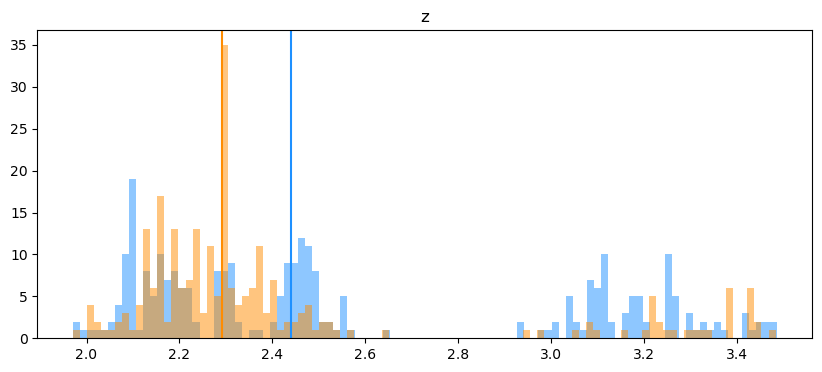

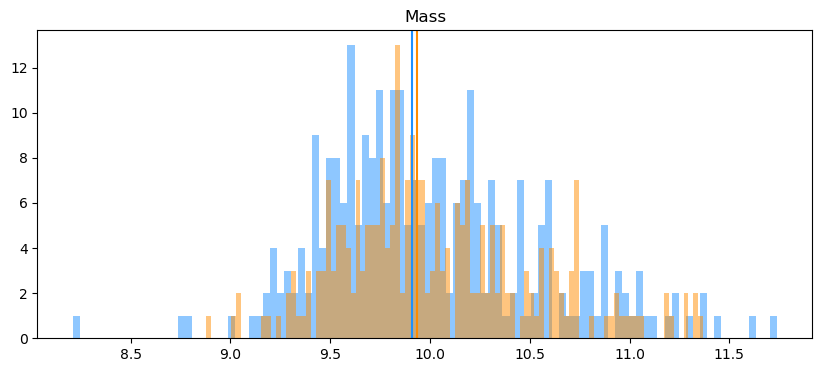

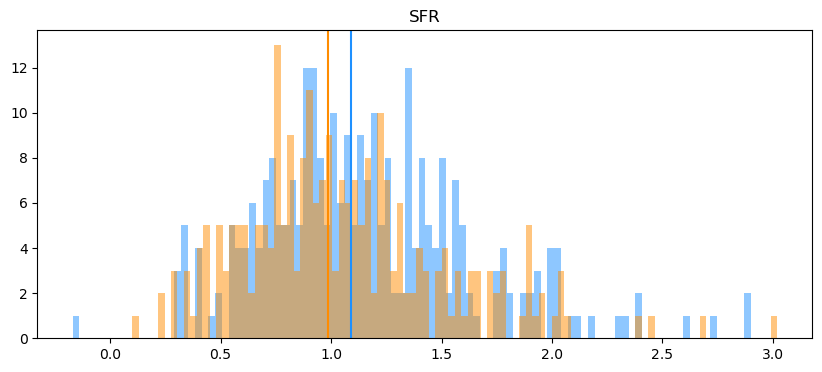

In [86]:
plt.figure(figsize=(10, 4))
plt.title('z')
plt.hist(cat_cos_mos['z'], 100, alpha=0.5, color='dodgerblue')
plt.axvline(np.nanmedian(cat_cos_mos['z']), color='dodgerblue')
plt.hist(cat_egs_mos['z'], 100, alpha=0.5, color='darkorange')
plt.axvline(np.nanmedian(cat_egs_mos['z']), color='darkorange')

plt.figure(figsize=(10, 4))
plt.title('Mass')
plt.hist(cat_cos_mos['MASS_50'], 100, alpha=0.5, color='dodgerblue')
plt.axvline(np.nanmedian(cat_cos_mos['MASS_50']), color='dodgerblue')
plt.hist(cat_egs_mos['MASS_50'], 100, alpha=0.5, color='darkorange')
plt.axvline(np.nanmedian(cat_egs_mos['MASS_50']), color='darkorange')

plt.figure(figsize=(10, 4))
plt.title('SFR')
plt.hist(cat_cos_mos[cat_cos_mos['SFR100_50'] > -1]['SFR100_50'], 100, alpha=0.5, color='dodgerblue')
plt.axvline(np.nanmedian(cat_cos_mos[cat_cos_mos['SFR100_50'] > -1]['SFR100_50']), color='dodgerblue')
plt.hist(cat_egs_mos[cat_egs_mos['SFR100_50'] > -1]['SFR100_50'], 100, alpha=0.5, color='darkorange')
plt.axvline(np.nanmedian(cat_egs_mos[cat_egs_mos['SFR100_50'] > -1]['SFR100_50']), color='darkorange')

In [84]:
catalog_mos

INDEX,FIELD,CATALOG,RA,DEC,z,MASS_16,MASS_50,MASS_84,SFR100_16,SFR100_50,SFR100_84,SFR10_16,SFR10_50,SFR10_84,E(B-V)_16,E(B-V)_50,E(B-V)_84,HA_FLUX,HA_FLUX_ERR,HA_SN,HA_FLAG,HA_FWHM,HA_FWHM_ERR,HB_FLUX,HB_FLUX_ERR,HB_SN,HB_FLAG,HB_FWHM,HB_FWHM_ERR,OII_FLUX,OII_FLUX_ERR,OII_SN,OII_FLAG,OII3727_FLUX,OII3727_FLUX_ERR,OII3727_SN,OII3727_FLAG,OII3727_FWHM,OII3727_FWHM_ERR,OII3730_FLUX,OII3730_FLUX_ERR,OII3730_SN,OII3730_FLAG,OII3730_FWHM,OII3730_FWHM_ERR,OIII_FLUX,OIII_FLUX_ERR,OIII_SN,OIII_FLAG,OIII4960_FLUX,OIII4960_FLUX_ERR,OIII4960_SN,OIII4960_FLAG,OIII4960_FWHM,OIII4960_FWHM_ERR,OIII5008_FLUX,OIII5008_FLUX_ERR,OIII5008_SN,OIII5008_FLAG,OIII5008_FWHM,OIII5008_FWHM_ERR,R814,R814_ERR,R160,R160_ERR,Z_16,Z_50,Z_84,BETA_16,BETA_50,BETA_84,AV_UV_16,AV_UV_50,AV_UV_84,O3,O32,E_BV_NEB_16,E_BV_NEB_50,E_BV_NEB_84,E_BV_STAR_TO_NEB_16,E_BV_STAR_TO_NEB_50,E_BV_STAR_TO_NEB_84,O3_ERR,O32_ERR
int64,str6,str6,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str5,float64,float64,float64,float64,float64,str5,float64,float64,float64,float64,float64,str5,float64,float64,float64,str5,float64,float64,float64,float64,float64,str5,float64,float64,float64,float64,float64,str5,float64,float64,float64,str5,float64,float64,float64,float64,float64,str5,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
664,COSMOS,MOSDEF,150.156509,2.19559,2.4358,10.180000305175781,10.180000305175781,10.239999771118164,1.2799999713897705,1.5499999523162842,1.5499999523162842,nan,nan,nan,0.08395061641931534,0.14814814925193787,0.15308640897274017,4.4216346e-17,2.2145998e-18,19.965840329254974,True,13.158913,0.0,1.2872932e-17,4.6098313e-18,2.792495248144981,False,11.852858,2.628091,nan,nan,0.0,False,2.0627715e-17,5.3672275e-18,3.843271968628123,True,6.4530783,1.0514379,1.2552455e-17,2.1202356e-18,5.920311403128973,True,6.457857,1.0522165,nan,nan,0.0,False,9.9664941e-18,1.116428e-18,8.927126603775612,True,10.986042,1.2571869,3.1803476e-17,2.4093086e-18,13.200250063441436,True,12.64133,1.2157321,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.3400000035762787,0.6000000238418579,0.6200000047683716,nan,0.09998555756613722,-0.09620085548120068,0.1472565802232162,0.4787464409008739,0.19079685549844394,0.3367003392089497,0.34792365675622766,nan,0.08042195897542062
665,COSMOS,MOSDEF,150.148407,2.213134,2.3072,10.539999961853027,10.569999694824219,10.569999694824219,1.2400000095367432,1.2400000095367432,1.5800000429153442,nan,nan,nan,0.14320985972881317,0.14814814925193787,0.2222222089767456,1.4500233e-16,4.9832226e-18,29.09810410636683,True,13.035181,0.23706194,3.3059961e-17,5.4278376e-18,6.090816165907395,True,10.502865,1.7356971,nan,nan,0.0,False,3.5764298e-17,5.893735e-18,6.068189017660278,True,7.4080863,0.21006407,4.3991677e-17,2.5789214e-18,17.058168969399375,True,7.4135721,0.21021963,nan,nan,0.0,False,1.4498972e-17,2.8735052e-18,5.045744131592315,True,10.906061,2.443237,3.1268145e-17,1.845442e-18,16.943444984995466,True,7.7417817,0.58031267,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.5799999833106995,0.6000000238418579,0.8999999761581421,0.1412512189430384,-0.24120967270835172,0.22444095801723968,0.3562649282671747,0.5199694850323149,0.32547695392912085,0.3367003392089497,0.505050474947149,0.07832185518755445,0.04772152286252417
666,COSMOS,MOSDEF,150.149673,2.191054,2.1003,10.779999732971191,10.779999732971191,10.779999732971191,2.3399999141693115,2.3399999141693115,2.3399999141693115,nan,nan,nan,0.32098764181137085,0.32098764181137085,0.32098764181137085,8.7939323e-17,1.9327332e-18,45.499980545685254,True,12.983066,0.0,-999.0,-999.0,0.0,False,-999.0,-999.0,nan,nan,0.0,False,-999.0,-999.0,0.0,False,-999.0,-999.0,-999.0,-999.0,0.0,False,-999.0,-999.0,nan,nan,0.0,False,5.3661448e-18,1.9027663e-18,2.8201807021703083,False,10.417138,3.0886789,9.9904169